In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
from keras.callbacks import EarlyStopping,ReduceLROnPlateau

2026-03-29 19:07:25.313005: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774811245.496869      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774811245.547772      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774811245.960429      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774811245.960466      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774811245.960469      55 computation_placer.cc:177] computation placer alr

In [2]:
data_path = '/kaggle/input/datasets/hasibalmuzdadid/shoe-vs-sandal-vs-boot-dataset-15k-images/Shoe vs Sandal vs Boot Dataset'

In [3]:
images_class = os.listdir('/kaggle/input/datasets/hasibalmuzdadid/shoe-vs-sandal-vs-boot-dataset-15k-images/Shoe vs Sandal vs Boot Dataset')
images_class

['Shoe', 'Sandal', 'Boot']

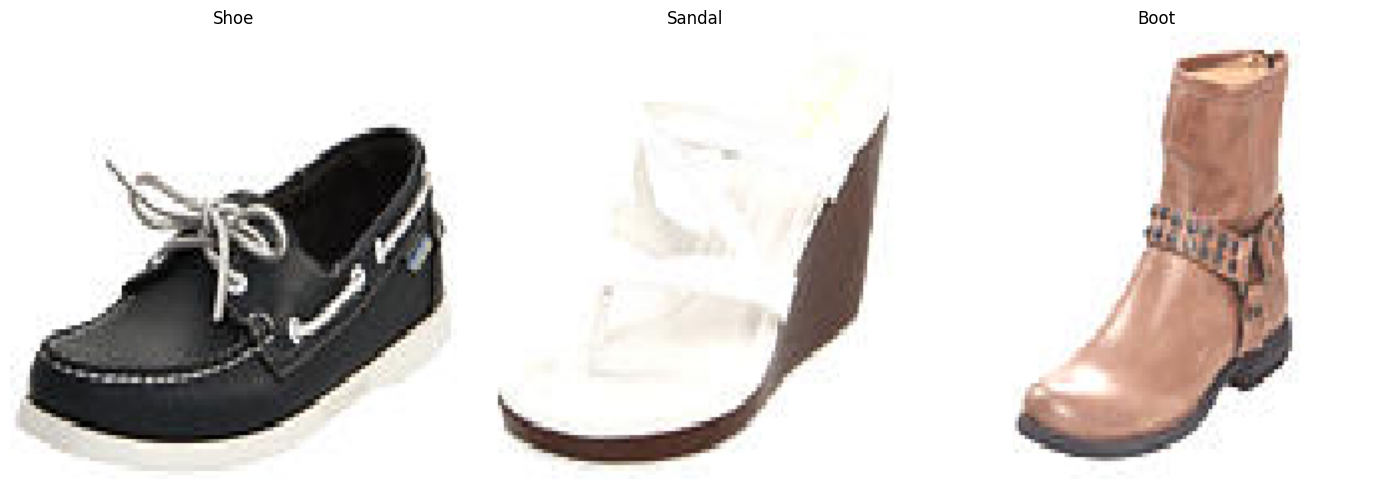

In [4]:
def plot_images(images_class):
    plt.figure(figsize=(14, 6))
    
    for i, category in enumerate(images_class):
        image_path = os.path.join(data_path, category)
        images_in_folder = os.listdir(image_path)
        
        if len(images_in_folder) == 0:
            continue
        
        first_image = images_in_folder[0]
        first_image_path = os.path.join(image_path, first_image)
        
        img = image.load_img(first_image_path, target_size=(224, 224))
        img_array = image.img_to_array(img) / 255.0
        
        plt.subplot(1, len(images_class), i + 1)
        plt.imshow(img_array)
        plt.title(category)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()


plot_images(images_class)

In [5]:
base_dir = '/kaggle/working/shoe-vs-sandal-vs-boot'
os.makedirs(base_dir, exist_ok=True)
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

In [6]:
import os
import shutil
from sklearn.model_selection import train_test_split

for category in images_class:
    src_folder = os.path.join(data_path, category)
    images = os.listdir(src_folder)

    # 80% train, 20% temp
    train_imgs, temp_imgs = train_test_split(
        images, test_size=0.2, random_state=42
    )

    # 10% val, 10% test
    val_imgs, test_imgs = train_test_split(
        temp_imgs, test_size=0.5, random_state=42
    )

    for folder, img_list in zip(
        [train_dir, val_dir, test_dir],
        [train_imgs, val_imgs, test_imgs]
    ):
        dest = os.path.join(folder, category)
        os.makedirs(dest, exist_ok=True)

        for img_name in img_list:
            shutil.copy(
                os.path.join(src_folder, img_name),
                os.path.join(dest, img_name)
            )

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.25, 
    height_shift_range=0.25,
    shear_range=0.3,
    zoom_range=0.35,
    horizontal_flip=True
)

In [8]:
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [40]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(120,120),
    batch_size=50,
    class_mode='categorical',
    shuffle=True,
    seed=42
)


Found 12000 images belonging to 3 classes.


In [41]:

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(120,120),
    batch_size=50,
    class_mode='categorical',
    shuffle=False
)

Found 1500 images belonging to 3 classes.


In [42]:
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(120,120),
    batch_size=50,
    class_mode='categorical',
    shuffle=False
)

Found 1500 images belonging to 3 classes.


# inception with factorization 

In [43]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Concatenate, Lambda, Activation, Multiply, BatchNormalization
import tensorflow as tf

def inception_module_factorized(x, filters):
    f1, f3, f5, f_pool = filters

    # 1x1
    conv1 = Conv2D(f1, (1,1), padding='same', use_bias=False)(x)
    conv1 = Activation('relu')(conv1)

    # 3x3 factorized
    conv3 = Conv2D(f3, (1,1), padding='same', use_bias=False)(x)
    conv3 = Activation('relu')(conv3)

    conv3 = Conv2D(f3, (1,3), padding='same', use_bias=False)(conv3)
    conv3 = Activation('relu')(conv3)

    conv3 = Conv2D(f3, (3,1), padding='same', use_bias=False)(conv3)
    conv3 = Activation('relu')(conv3)

    # 5x5 factorized
    conv5 = Conv2D(f5, (1,1), padding='same', use_bias=False)(x)
    conv5 = Activation('relu')(conv5)

    conv5 = Conv2D(f5, (1,3), padding='same', use_bias=False)(conv5)
    conv5 = Activation('relu')(conv5)

    conv5 = Conv2D(f5, (3,1), padding='same', use_bias=False)(conv5)
    conv5 = Activation('relu')(conv5)

    conv5 = Conv2D(f5, (1,3), padding='same', use_bias=False)(conv5)
    conv5 = Activation('relu')(conv5)

    conv5 = Conv2D(f5, (3,1), padding='same', use_bias=False)(conv5)
    conv5 = Activation('relu')(conv5)

    # pooling branch
    pool = MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    pool = Conv2D(f_pool, (1,1), padding='same', use_bias=False)(pool)
    pool = Activation('relu')(pool)

    # concat feature map
    feature_map = Concatenate()([conv1, conv3, conv5, pool])

    # spatial attention
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(feature_map)
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(feature_map)

    concat = Concatenate(axis=-1)([max_pool, avg_pool])

    attention = Conv2D(1, (7,7), padding='same', use_bias=False)(concat)
    attention = Activation('sigmoid')(attention)

    # element-wise multiplication
    output = Multiply()([feature_map, attention])

    return output

In [44]:
from keras.models import Model
inputs = Input(shape=(120,120,3))

x = Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
x = MaxPooling2D()(x)

# Inception Block 1
x = inception_module_factorized(x, [32, 32, 32, 32])
x = MaxPooling2D()(x)

# Inception Block 2
x = inception_module_factorized(x, [64, 64, 64, 64])
x = MaxPooling2D()(x)

# Inception Block 3
x = inception_module_factorized(x, [128, 128, 128, 128])
x = MaxPooling2D()(x)


x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)

outputs = Dense(3, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 120, 120,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_102 (Conv2D) │ (None, 120, 120,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 60, 60,    │          0 │ conv2d_102[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_107 (Conv2D) │ (None, 60, 60,    │      1,024 │ max_pooling2d_21… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_103      │ (None, 60, 60,    │          0 │ conv2d_107[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_108 (Conv2D) │ (None, 60, 60,    │      3,072 │ activation_103[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_104      │ (None, 60, 60,    │          0 │ conv2d_108[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_104 (Conv2D) │ (None, 60, 60,    │      1,024 │ max_pooling2d_21… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_109 (Conv2D) │ (None, 60, 60,    │      3,072 │ activation_104[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_100      │ (None, 60, 60,    │          0 │ conv2d_104[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_105      │ (None, 60, 60,    │          0 │ conv2d_109[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_105 (Conv2D) │ (None, 60, 60,    │      3,072 │ activation_100[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_110 (Conv2D) │ (None, 60, 60,    │      3,072 │ activation_105[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_22    │ (None, 60, 60,    │          0 │ max_pooling2d_21… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_101      │ (None, 60, 60,    │          0 │ conv2d_105[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_106      │ (None, 60, 60,    │          0 │ conv2d_110[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_112 (Conv2D) │ (None, 60, 60,    │      1,024 │ max_pooling2d_22

 Total params: 6,980,649 (26.63 MB)

 Trainable params: 6,980,201 (26.63 MB)

 Non-trainable params: 448 (1.75 KB)

In [45]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [46]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [47]:
reduce_lr =ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [48]:
model_history = model.fit(
    train_generator,
    epochs=60,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 65s 205ms/step - accuracy: 0.5482 - loss: 1.1485 - val_accuracy: 0.3333 - val_loss: 1.1209 - learning_rate: 0.0010
Epoch 2/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 46s 193ms/step - accuracy: 0.7247 - loss: 0.6432 - val_accuracy: 0.3340 - val_loss: 2.8775 - learning_rate: 0.0010
Epoch 3/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 46s 190ms/step - accuracy: 0.8056 - loss: 0.4865 - val_accuracy: 0.7140 - val_loss: 0.9011 - learning_rate: 0.0010
Epoch 4/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 46s 190ms/step - accuracy: 0.8516 - loss: 0.3896 - val_accuracy: 0.5440 - val_loss: 3.7993 - learning_rate: 0.0010
Epoch 5/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 46s 191ms/step - accuracy: 0.8602 - loss: 0.3634 - val_accuracy: 0.8493 - val_loss: 0.4047 - learning_rate: 0.0010
Epoch 6/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 46s 191ms/step - accuracy: 0.8792 - loss: 0.3131 - val_accuracy: 0.3707 - val_loss: 3.0971 - learning_rate: 0.0010
Epoch 7/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 46s 190ms/step - accuracy: 0.8

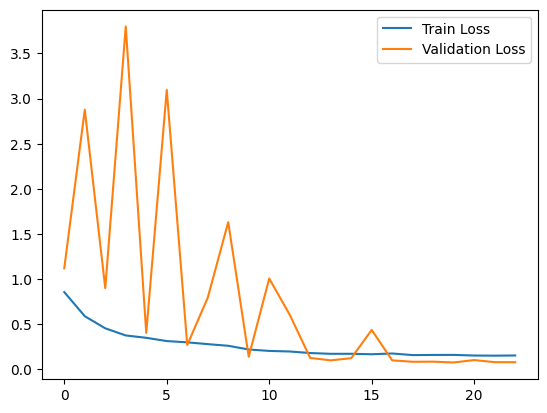

In [49]:
plt.plot(model_history.history['loss'], label = 'Train Loss')
plt.plot(model_history.history['val_loss'], label = 'Validation Loss')
plt.legend() 
plt.show()   

In [50]:
model.evaluate(test_generator)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9737 - loss: 0.0864


[0.12847989797592163, 0.9633333086967468]

In [51]:
test_generator.reset()  
pred = model.predict(test_generator, verbose=1)

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step


In [52]:
y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys()) 

In [53]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

In [54]:
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.9633
Precision: 0.9633
Recall:    0.9633
F1 Score:  0.9633


In [55]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[491   6   3]
 [  6 476  18]
 [  6  16 478]]


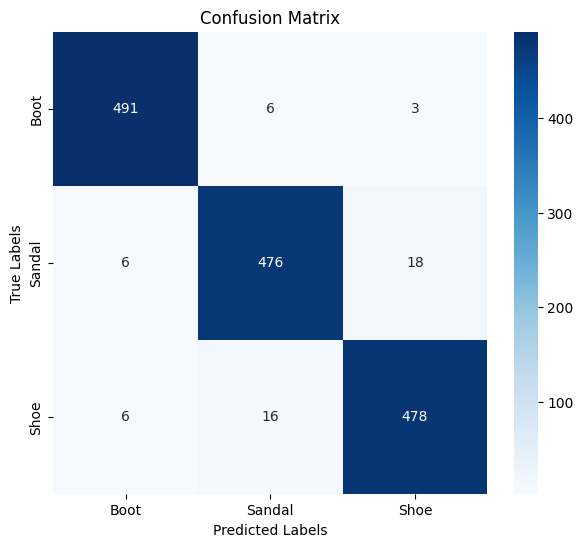

In [56]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()